# 揽宝智能投研交易平台 - 快速入门

本 Notebook 介绍如何使用揽宝平台进行量化策略研究。

## 1. 环境设置

In [1]:
# 导入必要的库
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 揽宝模块
from lanbao_data.tushare_adapter import TushareAdapter
from lanbao_data.duckdb_storage import DuckDBStorage
from lanbao_strategy.strategy_template import MovingAverageCrossStrategy
from lanbao_backtest.backtest_engine import BacktestEngine, BacktestConfig

## 2. 数据获取

In [2]:
# 初始化Tushare适配器
# 注意: 需要设置 TUSHARE_TOKEN 环境变量
tushare = TushareAdapter()

# 获取股票日线数据
symbol = "000001.SZ"  # 平安银行
data = tushare.get_daily_data(symbol, start_date="20230101", end_date="20241231")

print(f"获取到 {len(data)} 条数据")
data.tail(10)

2026-02-09 07:54:49.952 | INFO     | lanbao_data.tushare_adapter:__init__:36 - Tushare适配器初始化完成
2026-02-09 07:54:50.077 | DEBUG    | lanbao_data.tushare_adapter:get_daily_data:115 - 获取 000001.SZ 日线数据: 484 条


获取到 484 条数据


,symbol,date,open,high,low,close,pre_close,change,pct_chg,volume,amount,data_source
9,000001.SZ,2024-12-18,11.58,11.74,11.57,11.65,11.53,0.12,1.0408,1016589.66,1186285.805,tushare
8,000001.SZ,2024-12-19,11.59,11.64,11.54,11.59,11.65,-0.06,-0.5150,697379.04,808465.664,tushare
7,000001.SZ,2024-12-20,11.59,11.70,11.58,11.62,11.59,0.03,0.2588,714646.27,831437.460,tushare
6,000001.SZ,2024-12-23,11.64,11.84,11.64,11.73,11.62,0.11,0.9466,1659404.76,1953519.499,tushare
5,000001.SZ,2024-12-24,11.72,11.87,11.72,11.86,11.73,0.13,1.1083,1350836.91,1595698.790,tushare
4,000001.SZ,2024-12-25,11.86,12.02,11.84,11.92,11.86,0.06,0.5059,1475282.94,1759956.630,tushare
3,000001.SZ,2024-12-26,11.92,11.93,11.78,11.86,11.92,-0.06,-0.5034,1000074.70,1183745.519,tushare
2,000001.SZ,2024-12-27,11.87,11.90,11.66,11.83,11.86,-0.03,-0.2530,1290012.28,1518383.345,tushare
1,000001.SZ,2024-12-30,11.78,11.97,11.78,11.95,11.83,0.12,1.0144,1351846.36,1610892.096,tushare
0,000001.SZ,2024-12-31,11.93,11.99,11.70,11.70,11.95,-0.25,-2.0921,1475367.33,1747242.074,tushare


## 3. 数据存储

In [3]:
# 初始化DuckDB存储
storage = DuckDBStorage("../data/lanbao.duckdb" )

# 保存数据
print(data.columns)
print(type(data))
data.rename(columns={"pct_chg":"change_pct"}, inplace=True)
storage.save_daily_data(symbol, data)

# 查询数据
stored_data = storage.get_daily_data(symbol, start_date="2024-01-14")
print(f"存储的数据: {len(stored_data)} 条")

IOException: IO Error: Could not set lock on file "/workspace/notebooks/../data/lanbao.duckdb": Conflicting lock is held in PID 0. See also https://duckdb.org/docs/stable/connect/concurrency

## 4. 策略开发

In [4]:
# 创建双均线交叉策略
strategy = MovingAverageCrossStrategy(
    strategy_id="ma_demo",
    name="演示策略",
    fast_period=5,
    slow_period=20
)

# 分析数据
analysis = strategy.analyze(data)
print(f"趋势: {analysis['trend']}，强度: {analysis['trend_strength']:.2%}")

# 生成信号
signals = strategy.generate_signals(data)
print(f"生成 {len(signals)} 个信号")
for signal in signals[-5:]:
    print(f"  {signal.timestamp}: {signal.action} - {signal.reason}")

趋势: UP，强度: 1.31%
生成 0 个信号


## 5. 回测

In [5]:
# 配置回测引擎
config = BacktestConfig(
    initial_capital=100000,
    commission_rate=0.0003,
    slippage=0.001
)

engine = BacktestEngine(config)

# 定义信号生成器
def ma_cross_signal(data):
    df = data.copy()
    df['ma5'] = df['close'].rolling(5).mean()
    df['ma20'] = df['close'].rolling(20).mean()
    
    signal = pd.Series(0, index=df.index)
    signal[df['ma5'] > df['ma20']] = 1
    signal[df['ma5'] < df['ma20']] = -1
    return signal

# 运行回测
result = engine.run_backtest(
    strategy_id="ma_cross",
    symbol=symbol,
    data=data,
    signal_generator=ma_cross_signal
)

# 查看结果
print(f"回测ID: {result.backtest_id}")
print(f"总收益: {result.total_return:.2%}")
print(f"年化收益: {result.annual_return:.2%}")
print(f"夏普比率: {result.sharpe_ratio:.2f}")
print(f"最大回撤: {result.max_drawdown:.2%}")
print(f"胜率: {result.win_rate:.2%}")
print(f"交易次数: {result.total_trades}")

2026-02-09 07:54:57.239 | INFO     | lanbao_backtest.backtest_engine:run_backtest:111 - 开始回测: bt_ma_cross_20260209_075457 for 000001.SZ
2026-02-09 07:54:57.254 | INFO     | lanbao_backtest.backtest_engine:run_backtest:131 - 回测完成: bt_ma_cross_20260209_075457, 总收益: 0.32%


回测ID: bt_ma_cross_20260209_075457
总收益: 0.32%
年化收益: 0.17%
夏普比率: -1.37
最大回撤: -3.85%
胜率: 38.89%
交易次数: 36


## 6. 可视化

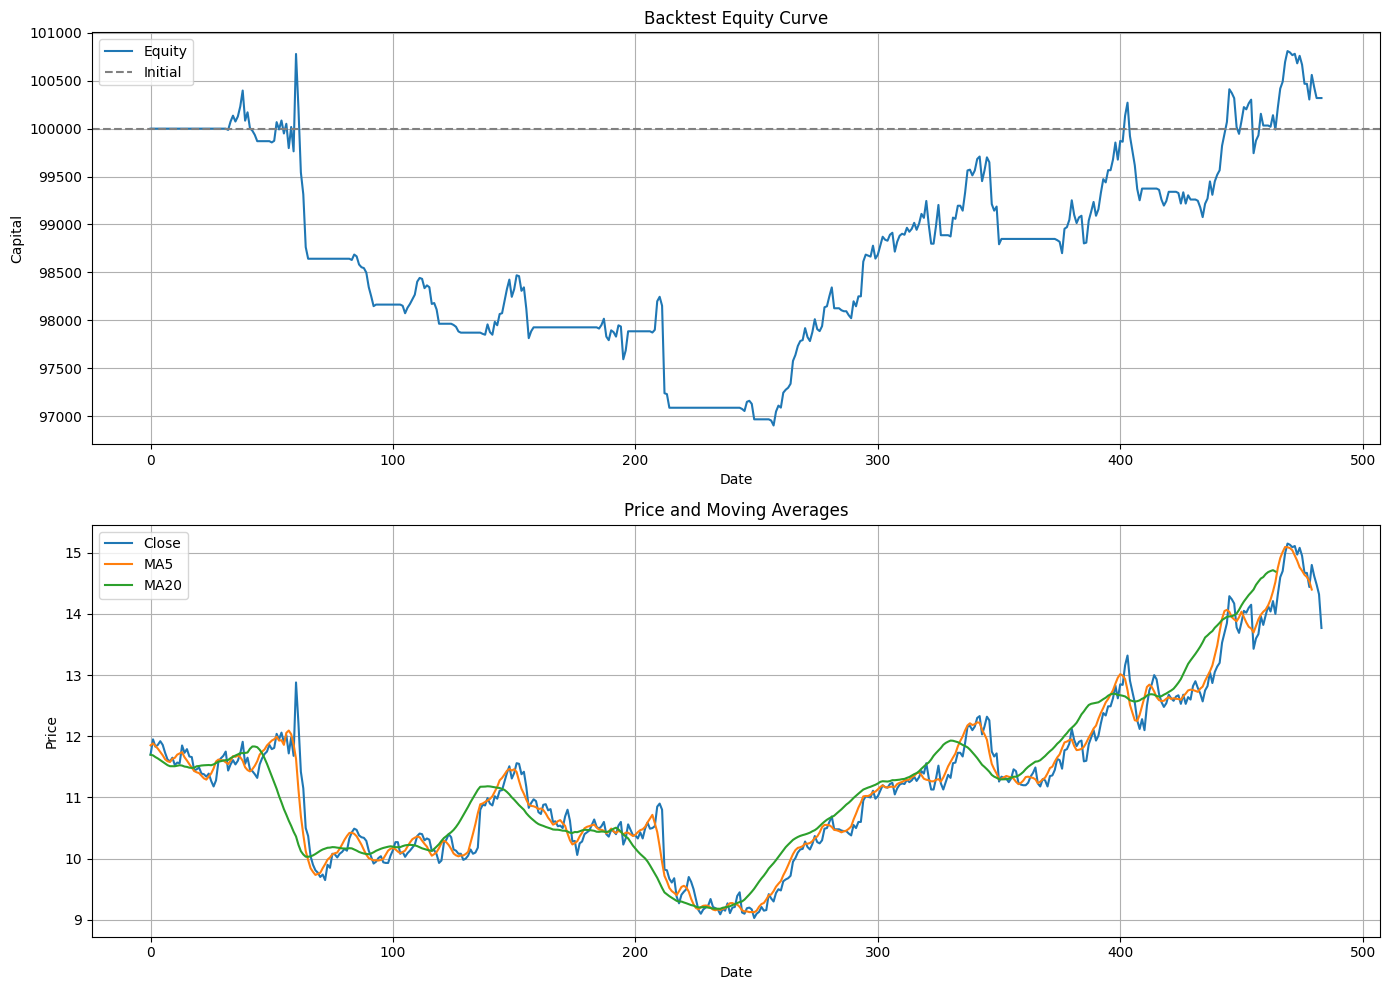

In [6]:
# 绘制权益曲线
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 权益曲线
ax1 = axes[0]
result.equity_curve.plot(ax=ax1, label='Equity')
ax1.axhline(y=config.initial_capital, color='gray', linestyle='--', label='Initial')
ax1.set_title('Backtest Equity Curve')
ax1.set_xlabel('Date')
ax1.set_ylabel('Capital')
ax1.legend()
ax1.grid(True)

# 价格和均线
ax2 = axes[1]
data['close'].plot(ax=ax2, label='Close')
data['close'].rolling(5).mean().plot(ax=ax2, label='MA5')
data['close'].rolling(20).mean().plot(ax=ax2, label='MA20')
ax2.set_title('Price and Moving Averages')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 7. 绩效分析

In [7]:
from lanbao_backtest.performance_analyzer import PerformanceAnalyzer

analyzer = PerformanceAnalyzer()
analysis = analyzer.analyze(result)

# 打印分析报告
print("=" * 50)
print("回测绩效分析报告")
print("=" * 50)

print("\n【基本信息】")
for k, v in analysis['summary'].items():
    print(f"  {k}: {v}")

print("\n【收益指标】")
for k, v in analysis['returns'].items():
    if isinstance(v, float):
        print(f"  {k}: {v:.2%}" if 'return' in k else f"  {k}: {v:.4f}")

print("\n【风险指标】")
for k, v in analysis['risk'].items():
    if isinstance(v, float):
        print(f"  {k}: {v:.2%}" if ('drawdown' in k) or ('volatility' in k) else f"  {k}: {v:.2f}")

print("\n【交易统计】")
for k, v in analysis['trades'].items():
    if isinstance(v, float):
        print(f"  {k}: {v:.2%}" if 'rate' in k else f"  {k}: {v:.2f}")
    else:
        print(f"  {k}: {v}")

/workspace/install/lanbao_backtest/lib/python3.10/site-packages/lanbao_backtest/performance_analyzer.py:165: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = equity.resample('M').last()


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

## 8. 多策略对比

2026-02-09 07:55:03.046 | INFO     | lanbao_backtest.backtest_engine:run_backtest:111 - 开始回测: bt_demo_MA5/20_20260209_075503 for 000001.SZ
2026-02-09 07:55:03.068 | INFO     | lanbao_backtest.backtest_engine:run_backtest:131 - 回测完成: bt_demo_MA5/20_20260209_075503, 总收益: 0.32%


             总收益      年化收益      夏普比率     最大回撤        胜率  交易次数
MA5/20  0.003194  0.001662 -1.366179 -0.03848  0.388889  36.0


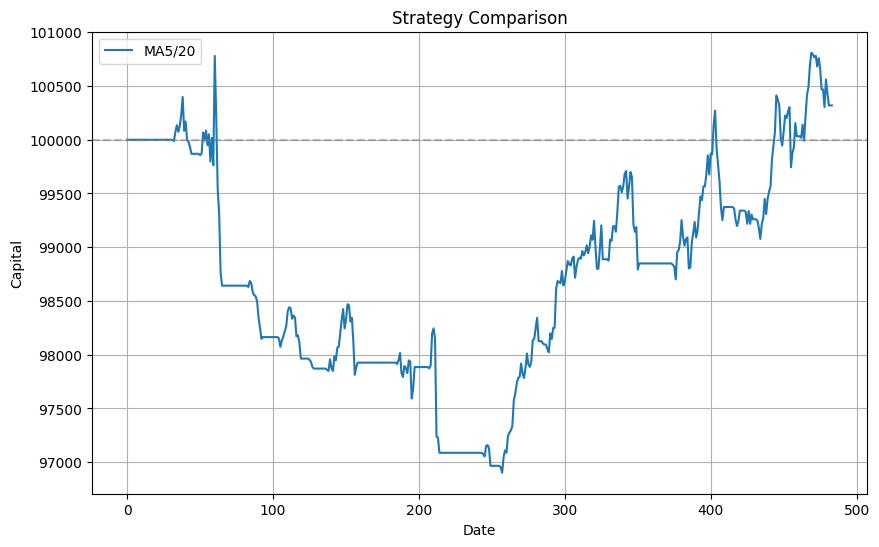

In [8]:
# 运行多个策略
strategies = {
    'MA5/20': ma_cross_signal,
}

results = {}
for name, signal_func in strategies.items():
    result = engine.run_backtest(
        strategy_id=f"demo_{name}",
        symbol=symbol,
        data=data,
        signal_generator=signal_func
    )
    results[name] = result

# 对比
comparison = pd.DataFrame({
    name: {
        '总收益': r.total_return,
        '年化收益': r.annual_return,
        '夏普比率': r.sharpe_ratio,
        '最大回撤': r.max_drawdown,
        '胜率': r.win_rate,
        '交易次数': r.total_trades
    }
    for name, r in results.items()
}).T

print(comparison)

# 可视化对比
fig, ax = plt.subplots(figsize=(10, 6))
for name, result in results.items():
    result.equity_curve.plot(ax=ax, label=name)
ax.axhline(y=config.initial_capital, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Strategy Comparison')
ax.set_xlabel('Date')
ax.set_ylabel('Capital')
ax.legend()
ax.grid(True)
plt.show()

## 9. 保存结果

In [9]:
# 保存回测结果
storage.save_backtest_result({
    'backtest_id': result.backtest_id,
    'strategy_id': result.strategy_id,
    'symbol': result.symbol,
    'start_date': result.start_date,
    'end_date': result.end_date,
    'total_return': result.total_return,
    'annual_return': result.annual_return,
    'sharpe_ratio': result.sharpe_ratio,
    'max_drawdown': result.max_drawdown,
    'volatility': result.volatility,
    'win_rate': result.win_rate,
    'trades_count': result.total_trades,
    'params': strategy.get_params()
})

# 查询历史回测
backtests = storage.get_backtest_results()
print(f"历史回测记录: {len(backtests)} 条")
backtests.head()

NameError: name 'storage' is not defined

## 10. 生成报告

In [10]:
# 生成HTML报告
html_report = analyzer.generate_report_html(result)

# 保存报告
report_path = f"../reports/backtest_{result.backtest_id}.html"
import os
os.makedirs("../reports", exist_ok=True)
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(html_report)

print(f"报告已保存: {report_path}")

/workspace/install/lanbao_backtest/lib/python3.10/site-packages/lanbao_backtest/performance_analyzer.py:165: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = equity.resample('M').last()


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

---

## 下一步

- 尝试修改策略参数，观察对回测结果的影响
- 开发自己的策略，继承 `StrategyTemplate` 类
- 使用ROS2节点进行实时数据处理和策略执行